In [25]:
# Cell 1: Imports and Configurations
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, BinaryAccuracy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tqdm
import matplotlib.pyplot as plt
import librosa.display
import random
from IPython.display import Audio, display

In [24]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
!unzip -q HF_lung_V1_RAW.zip -d /content/

In [26]:
# Audio & Window Configurations
TARGET_SR = 16000          # Standard sample rate for lung sounds
WINDOW_SEC = 2.0           # 2-second windows to capture full respiratory phases
HOP_SEC = 1.0              # Slide window by 1 second (50% overlap)
WINDOW_SAMPLES = int(TARGET_SR * WINDOW_SEC)
N_MELS = 64

# Translates your raw CSV text directly into your clean column names
LABEL_MAPPING = {
    'I': 'inhale',
    'E': 'exhale',
    'D': 'coarse_crackle',
    'Rhonchi': 'Rhonchi',
    'Ronchi': 'Rhonchi',
    'Stridor': 'stridor',
    'Wheeze': 'wheeze'
}

TARGET_CLASSES = ['inhale', 'exhale', 'Rhonchi', 'stridor', 'wheeze', 'coarse_crackle']
NUM_CLASSES = len(TARGET_CLASSES)

TRAIN_DIR = "HF_lung_V1_RAW/train/"
TEST_DIR = "HF_lung_V1_RAW/test/"
DF_PATH = "HF_lung_V1_RAW/HF_Lung_V1_annotations.csv"

In [27]:
df = pd.read_csv(DF_PATH)
df

,filename,split,label,start_time,end_time,duration
0,steth_20180814_09_37_11.wav,train,I,1.500,2.457,0.957
1,steth_20180814_09_37_11.wav,train,D,1.500,2.457,0.957
2,steth_20180814_09_37_11.wav,train,E,2.608,3.637,1.029
3,steth_20180814_09_37_11.wav,train,D,2.608,3.637,1.029
4,steth_20180814_09_37_11.wav,train,I,5.227,6.350,1.123
...,...,...,...,...,...,...
81928,trunc_2019-08-21-11-39-26-L8_9.wav,test,I,1.738,3.045,1.307
81929,trunc_2019-08-21-11-39-26-L8_9.wav,test,E,3.045,3.772,0.727
81930,trunc_2019-08-21-11-39-26-L8_9.wav,test,I,7.783,8.885,1.102
81931,trunc_2019-08-21-11-39-26-L8_9.wav,test,E,8.919,9.862,0.943


In [28]:
MIN_OVERLAP_SEC = 0.1  # Event must be present for at least 100ms inside the window

def build_windowed_dataframe(df_split, audio_dir, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    windowed_data = []
    grouped = df_split.groupby('filename')

    for filename, group in grouped:
        file_path = os.path.join(audio_dir, filename)

        try:
            total_duration = librosa.get_duration(path=file_path)
        except Exception as e:
            print(f"Skipping {filename}: {e}")
            continue

        current_start = 0.0

        while current_start + window_sec <= total_duration:
            current_end = current_start + window_sec
            window_labels = {cls: 0 for cls in TARGET_CLASSES}

            # Find events that generally overlap
            overlapping_events = group[
                (group['start_time'] < current_end) &
                (group['end_time'] > current_start)
            ]

            for _, event in overlapping_events.iterrows():
                # Calculate exactly HOW MUCH this event overlaps with our specific window
                actual_start = max(current_start, event['start_time'])
                actual_end = min(current_end, event['end_time'])
                overlap_duration = actual_end - actual_start

                # ONLY label it if it passes our strict threshold
                if overlap_duration >= MIN_OVERLAP_SEC:
                    raw_label = str(event['label']).strip()
                    mapped_label = LABEL_MAPPING.get(raw_label, raw_label)

                    if mapped_label in window_labels:
                        window_labels[mapped_label] = 1

            row_data = {
                'filename': filename,
                'file_path': file_path,
                'window_start': current_start,
                'window_end': current_end
            }
            row_data.update(window_labels)
            windowed_data.append(row_data)

            current_start += hop_sec

    return pd.DataFrame(windowed_data)

In [29]:
# 1. Filter the raw CSV by the 'split' column
train_df_raw = df[df['split'].str.lower() == 'train']
test_df_raw = df[df['split'].str.lower() == 'test']

# 2. Build the two independent DataFrames
windowed_train_df = build_windowed_dataframe(train_df_raw, TRAIN_DIR)
windowed_test_df = build_windowed_dataframe(test_df_raw, TEST_DIR)

print(f"Train windows: {len(windowed_train_df)} | Test windows: {len(windowed_test_df)}")

Train windows: 108570 | Test windows: 27328


In [30]:
OPTIMAL_FMAX = 1500
N_FFT = 1024
HOP_LENGTH = 512

def visualize_and_listen(df_raw, audio_dir):
    random_file = random.choice(df_raw['filename'].unique())
    file_path = os.path.join(audio_dir, random_file)
    file_labels = df_raw[df_raw['filename'] == random_file]

    print(f"--- Analyzing: {random_file} ---")

    try:
        y, sr = librosa.load(file_path, sr=TARGET_SR)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return

    # 1. Forward Pass
    mel_linear = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=OPTIMAL_FMAX
    )
    mel_db = librosa.power_to_db(mel_linear, ref=np.max)

    # 2. Reverse Pass (Griffin-Lim)
    y_regenerated = librosa.feature.inverse.mel_to_audio(
        mel_linear,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmax=OPTIMAL_FMAX
    )

    # 3. Display Playable Audio Players
    print("\n🎧 Original Audio:")
    display(Audio(data=y, rate=sr))

    print("\n🎧 Regenerated Audio (What the Model 'Hears'):")
    display(Audio(data=y_regenerated, rate=sr))

    # 4. Plotting
    fig, ax = plt.subplots(nrows=2, figsize=(14, 10), sharex=True)

    # --- Top Plot: Spectrogram ---
    librosa.display.specshow(
        mel_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='mel',
        fmax=OPTIMAL_FMAX,
        cmap='inferno',
        ax=ax[0]
    )
    ax[0].set_title(f'Optimized Mel-Spectrogram (0-{OPTIMAL_FMAX}Hz)')

    for _, row in file_labels.iterrows():
        start = row['start_time']
        end = row['end_time']
        raw_label = str(row['label']).strip()
        clean_label = LABEL_MAPPING.get(raw_label, raw_label)

        ax[0].axvspan(start, end, color='white', alpha=0.15)
        ax[0].text(start + 0.05, OPTIMAL_FMAX * 0.85, clean_label, color='white', fontsize=10, fontweight='bold', rotation=90)

    # --- Bottom Plot: Waveform Overlay ---
    # Solid blue for the original baseline
    librosa.display.waveshow(y, sr=sr, alpha=0.8, label='Original', color="#024b80", ax=ax[1])

    # Highly transparent red overlay for the regenerated wave
    librosa.display.waveshow(y_regenerated, sr=sr, alpha=0.4, label='Regenerated', color="#d34242", ax=ax[1])

    ax[1].set_title("Waveform Overlay")
    ax[1].set_ylabel("Amplitude")
    ax[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

--- Analyzing: trunc_2019-07-31-11-20-43-L4_11.wav ---

🎧 Original Audio:



🎧 Regenerated Audio (What the Model 'Hears'):


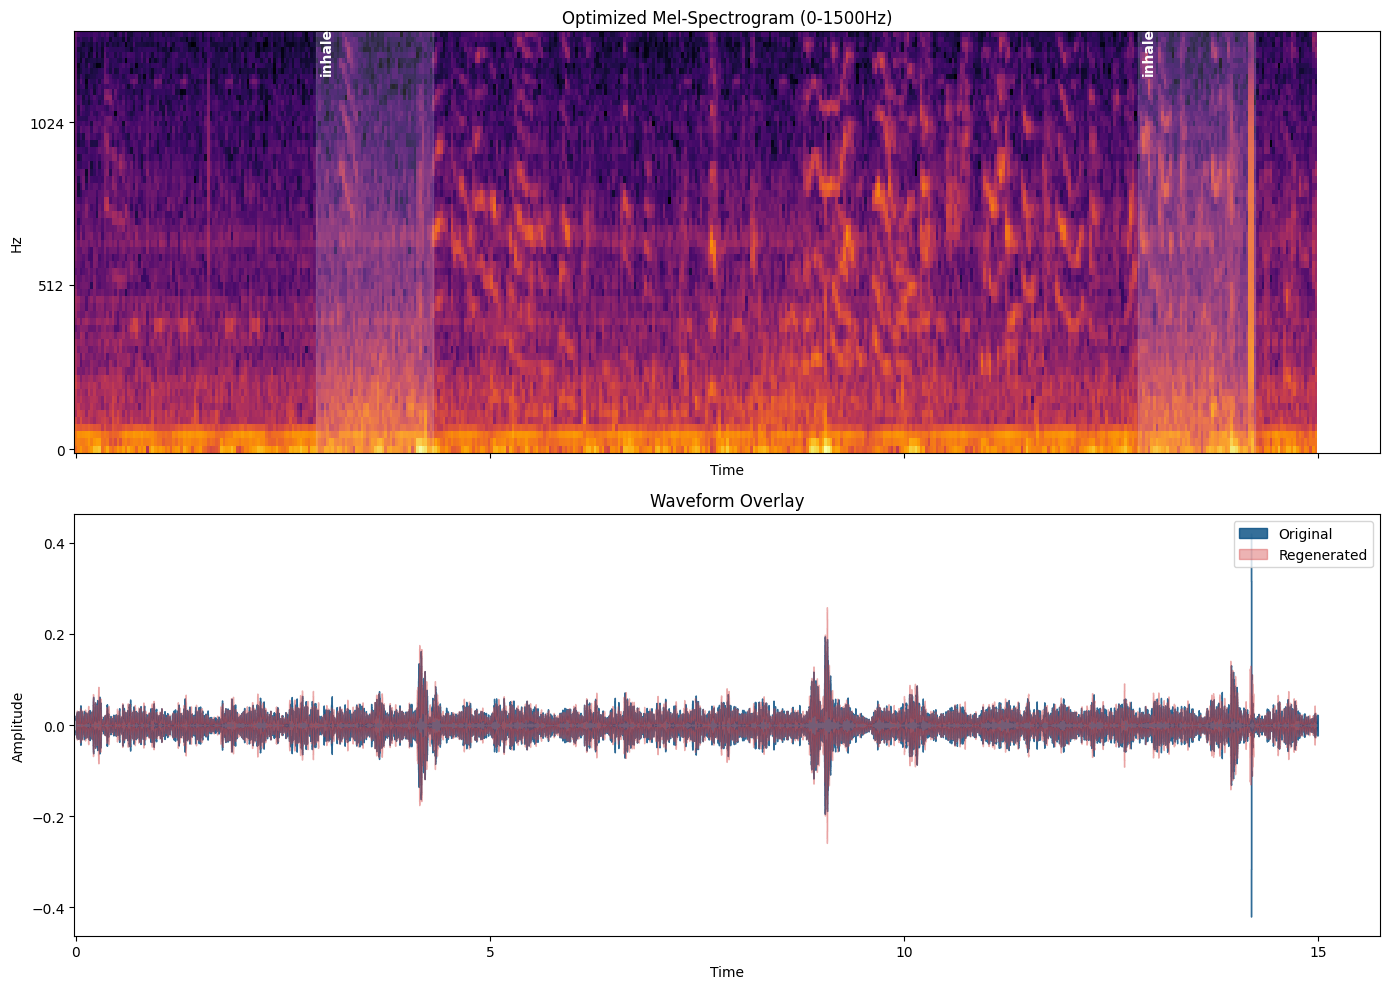

In [31]:
visualize_and_listen(train_df_raw, TRAIN_DIR)

In [32]:
BATCH_SIZE = 32

def load_and_preprocess_audio(file_path, start_time, label_array):
    """
    Loads exactly 2 seconds of audio from the specified start time,
    converts it to a 1200Hz Mel-spectrogram, and shapes it for ResNet50.
    """
    def _process(path, start):
        path = path.decode('utf-8')

        # Load exactly 2 seconds from the target offset
        y, sr = librosa.load(path, sr=TARGET_SR, offset=start, duration=WINDOW_SEC)

        # Pad with zeros if the audio chunk hits the end of the file early
        if len(y) < WINDOW_SAMPLES:
            y = np.pad(y, (0, WINDOW_SAMPLES - len(y)))

        # Generate Mel-Spectrogram utilizing our optimized 1200Hz cutoff
        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=1024,
            hop_length=512,
            n_mels=N_MELS,
            fmax=OPTIMAL_FMAX  # Using the 1200Hz limit
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # ResNet50 requires 3 color channels (RGB). We duplicate our grayscale spectrogram.
        mel_db = np.expand_dims(mel_db, axis=-1)       # (64, TimeSteps, 1)
        mel_db = np.repeat(mel_db, 3, axis=-1)         # (64, TimeSteps, 3)

        return mel_db.astype(np.float32)

    # Wrap Python function into the TensorFlow Graph execution
    spectrogram = tf.numpy_function(
        func=_process,
        inp=[file_path, start_time],
        Tout=tf.float32
    )

    # Explicitly define shapes so the neural network knows what to expect
    # 63 frames is standard for 2s at 16kHz with a 512 hop length
    spectrogram.set_shape([N_MELS, 63, 3])
    label_array.set_shape([NUM_CLASSES])

    return spectrogram, label_array


def create_tf_dataset(df, batch_size=BATCH_SIZE, is_training=True):
    """
    Creates an optimized tf.data pipeline that prefetches batches to the GPU.
    """
    paths = df['file_path'].values
    starts = df['window_start'].values.astype(np.float32)
    labels = df[TARGET_CLASSES].values.astype(np.float32)

    # Create the baseline dataset
    ds = tf.data.Dataset.from_tensor_slices((paths, starts, labels))

    # Shuffle completely before each epoch if this is the training set
    if is_training:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    # Map the preprocessing function across multiple CPU threads
    ds = ds.map(
        lambda p, s, l: load_and_preprocess_audio(p, s, l),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Batch the data and prefetch the next batch while the GPU is training
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [33]:
print("Building Training Dataset...")
train_ds = create_tf_dataset(windowed_train_df, is_training=True)

print("Building Testing Dataset...")
test_ds = create_tf_dataset(windowed_test_df, is_training=False)


for spec, labels in train_ds.take(1):
    print(f"Batch Spectrogram Shape: {spec.shape}")
    print(f"Batch Label Shape: {labels.shape}")

Building Training Dataset...
Building Testing Dataset...
Batch Spectrogram Shape: (32, 64, 63, 3)
Batch Label Shape: (32, 6)


In [34]:
def build_lung_resnet(input_shape=(N_MELS, 63, 3), num_classes=NUM_CLASSES):
    # 1. Define the input tensor
    inputs = Input(shape=input_shape)

    # 2. Load the pre-trained ResNet50 backbone
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,     # Drops the 1000-class ImageNet head
        input_tensor=inputs
    )

    # Freeze the backbone weights for initial training
    # This prevents the random weights of our new head from wrecking the pre-trained layers
    base_model.trainable = False

    # 3. Add our custom multi-label head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Flattens the 2D feature maps into a 1D vector
    x = Dropout(0.5)(x)              # Drops 50% of connections to prevent overfitting

    # CRITICAL: Sigmoid activation (not Softmax) allows multiple classes to be True at once
    outputs = Dense(num_classes, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # 4. Compile the model
    # BinaryCrossentropy treats every class as an independent Yes/No question
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            AUC(multi_label=True, name='auc'),
            BinaryAccuracy(name='accuracy')
        ]
    )

    return model

In [35]:
# Instantiate and check the architecture
model = build_lung_resnet()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 63, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 69, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
INITIAL_EPOCHS = 20

# 1. Define the Callbacks
callbacks = [
    # Stop training if the validation loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Drop the learning rate by 50% if the model plateaus (helps it settle into minimums)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    # Save the physical weights file ONLY when validation loss reaches a new low
    ModelCheckpoint(
        filepath='frozen_lung_resnet.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Starting Phase 1: Training the custom head (ResNet backbone is frozen)...")

# 2. Start the Training
# Note: We are using test_ds as our validation_data here
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

print("\nPhase 1 Complete. Best frozen model saved as 'frozen_lung_resnet.keras'")

Starting Phase 1: Training the custom head (ResNet backbone is frozen)...
Epoch 1/20
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8086 - auc: 0.6746 - loss: 0.4291
Epoch 1: val_loss improved from None to 0.36031, saving model to frozen_lung_resnet.keras

Epoch 1: finished saving model to frozen_lung_resnet.keras
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 951s 276ms/step - accuracy: 0.8172 - auc: 0.7034 - loss: 0.4029 - val_accuracy: 0.8503 - val_auc: 0.6719 - val_loss: 0.3603 - learning_rate: 0.0010
Epoch 2/20
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.8218 - auc: 0.7272 - loss: 0.3905
Epoch 2: val_loss did not improve from 0.36031
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 973s 275ms/step - accuracy: 0.8213 - auc: 0.7269 - loss: 0.3911 - val_accuracy: 0.8492 - val_auc: 0.6549 - val_loss: 0.3652 - learning_rate: 0.0010
Epoch 3/20
3393/3393 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8225 - auc: 0.7324 - loss: 0.3887
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005

In [37]:
# Cell 6: Model Evaluation
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

print("Running predictions on the test dataset...")
# 1. Generate probability predictions for the test set
# test_ds is unshuffled, so the order remains consistent
y_pred_probs = model.predict(test_ds)

# 2. Convert probabilities to binary predictions (0 or 1)
# 0.5 is the standard threshold: if probability > 50%, predict True
THRESHOLD = 0.5
y_pred_binary = (y_pred_probs >= THRESHOLD).astype(int)

# 3. Extract the actual ground-truth labels directly from the dataset
print("Extracting true labels...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 4. Calculate individual Area Under the Curve (AUC) for each class
print("\n--- ROC AUC Scores ---")
for i, class_name in enumerate(TARGET_CLASSES):
    # Try-except handles edge cases where a class might be entirely missing from the test set
    try:
        auc = roc_auc_score(y_true[:, i], y_pred_probs[:, i])
        print(f"{class_name.ljust(15)}: {auc:.4f}")
    except ValueError:
        print(f"{class_name.ljust(15)}: N/A (Not enough data in test split)")

# 5. Generate the full classification report
print("\n--- Classification Report ---")
print(
    classification_report(
        y_true,
        y_pred_binary,
        target_names=TARGET_CLASSES,
        zero_division=0
    )
)

Running predictions on the test dataset...
854/854 ━━━━━━━━━━━━━━━━━━━━ 186s 211ms/step
Extracting true labels...

--- ROC AUC Scores ---
inhale         : 0.7386
exhale         : 0.6809
Rhonchi        : 0.6443
stridor        : 0.5962
wheeze         : 0.6834
coarse_crackle : 0.6949

--- Classification Report ---
                precision    recall  f1-score   support

        inhale       0.75      0.78      0.76     17206
        exhale       0.46      0.38      0.42      7026
       Rhonchi       0.47      0.00      0.01      1920
       stridor       0.00      0.00      0.00        65
        wheeze       0.43      0.09      0.14      3092
coarse_crackle       0.45      0.05      0.10      3601

     micro avg       0.67      0.50      0.57     32910
     macro avg       0.43      0.22      0.24     32910
  weighted avg       0.61      0.50      0.51     32910
   samples avg       0.45      0.37      0.39     32910



In [38]:
%pip install mlflow
%pip install dagshub

In [39]:
# Cell 4.5: Log Existing Training Run to DagsHub
import dagshub
import mlflow
import matplotlib.pyplot as plt
import os

# 1. Initialize DagsHub Connection
# Replace with your actual DagsHub username and repository name
dagshub.init(repo_owner='RudhanLodhi', repo_name='Spectrolung', mlflow=True)

print("Pushing existing data to DagsHub MLflow...")

with mlflow.start_run(run_name="ResNet18_HF_lung"):

    # 2. Log Preprocessing & Hyperparameters
    mlflow.log_params({
        "target_sr": TARGET_SR,
        "window_sec": WINDOW_SEC,
        "hop_sec": HOP_SEC,
        "optimal_fmax": OPTIMAL_FMAX,
        "n_mels": N_MELS,
        "batch_size": BATCH_SIZE,
        "classes": TARGET_CLASSES,
        "model": "ResNet18"
    })

    # 3. Log Epoch Metrics & Generate Graphs
    # We check if the 'history' variable exists in memory from your previous model.fit()
    if 'history' in locals() or 'history' in globals():

        # Iterate through the history dictionary and log each step
        num_epochs = len(history.history['loss'])
        for epoch in range(num_epochs):
            for metric_name, metric_values in history.history.items():
                mlflow.log_metric(metric_name, metric_values[epoch], step=epoch)

        # Generate Training Curves Plot
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Plot Loss
        ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
        ax[0].plot(history.history['val_loss'], label='Val Loss', color='red')
        ax[0].set_title('Loss Curve')
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Binary Crossentropy')
        ax[0].legend()

        # Plot AUC (Using AUC instead of accuracy due to multi-label)
        if 'auc' in history.history:
            ax[1].plot(history.history['auc'], label='Train AUC', color='blue')
            ax[1].plot(history.history['val_auc'], label='Val AUC', color='red')
            ax[1].set_title('AUC Curve')
            ax[1].set_xlabel('Epoch')
            ax[1].set_ylabel('AUC')
            ax[1].legend()

        plt.tight_layout()

        # Upload the generated plot directly to MLflow without saving locally
        mlflow.log_figure(fig, "training_curves.png")
        plt.close(fig)
        print("Training curves and epoch metrics logged.")
    else:
        print("Warning: 'history' variable not found in memory. Epoch metrics skipped.")

    # 4. Upload the saved model weights
    # Checks if your ModelCheckpoint callback saved the file earlier
    model_filename = 'frozen_lung_resnet.keras'
    if os.path.exists(model_filename):
        mlflow.log_artifact(model_filename, artifact_path="models")
        print(f"Model file '{model_filename}' uploaded as artifact.")

print("\nRetrospective logging complete! Check your DagsHub repository for the UI.")

Initialized MLflow to track repo "RudhanLodhi/Spectrolung"

Repository RudhanLodhi/Spectrolung initialized!

Pushing existing data to DagsHub MLflow...
Training curves and epoch metrics logged.
Model file 'frozen_lung_resnet.keras' uploaded as artifact.
🏃 View run ResNet18_HF_lung at: https://dagshub.com/RudhanLodhi/Spectrolung.mlflow/#/experiments/0/runs/c2ee2134c131469989ec2fa8a9d38023
🧪 View experiment at: https://dagshub.com/RudhanLodhi/Spectrolung.mlflow/#/experiments/0

Retrospective logging complete! Check your DagsHub repository for the UI.


In [40]:
# Cell: Diagnostic Label Check
print("1. TARGET_CLASSES list being used:")
print(TARGET_CLASSES)

print("\n2. Unique labels present in raw TEST csv:")
# .unique() will reveal if there are hidden spaces or casing issues
print(test_df_raw['label'].unique())

print("\n3. Unique labels present in raw TRAIN csv (for comparison):")
print(train_df_raw['label'].unique())

print("\n4. Total positive windows generated in Test Dataset:")
print(windowed_test_df[TARGET_CLASSES].sum())

1. TARGET_CLASSES list being used:
['inhale', 'exhale', 'Rhonchi', 'stridor', 'wheeze', 'coarse_crackle']

2. Unique labels present in raw TEST csv:
['I' 'D' 'E' 'Wheeze' 'Stridor' 'Rhonchi']

3. Unique labels present in raw TRAIN csv (for comparison):
['I' 'D' 'E' 'Rhonchi' 'Wheeze' 'Stridor']

4. Total positive windows generated in Test Dataset:
inhale            17206
exhale             7026
Rhonchi            1920
stridor              65
wheeze             3092
coarse_crackle     3601
dtype: int64
